In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
mnist = tf.keras.datasets.mnist
(x_train, y_train),(x_test,y_test)=mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
x_train = tf.keras.utils.normalize(x_train , axis = 1)
x_test = tf.keras.utils.normalize(x_test , axis = 1)

In [ ]:
model= tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(units=128,activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(units=128,activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(units=10,activation=tf.nn.softmax))
model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
hist = model.fit(x_train,y_train, epochs=5)
print("The model has successfully trained")
model.evaluate(x_test,y_test)

Epoch 1/5
1875/1875 [==============================] - 11s 5ms/step - loss: 0.2677 - accuracy: 0.9204
Epoch 2/5
1875/1875 [==============================] - 8s 5ms/step - loss: 0.1084 - accuracy: 0.9668
Epoch 3/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0737 - accuracy: 0.9767
Epoch 4/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0544 - accuracy: 0.9826
Epoch 5/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0428 - accuracy: 0.9857


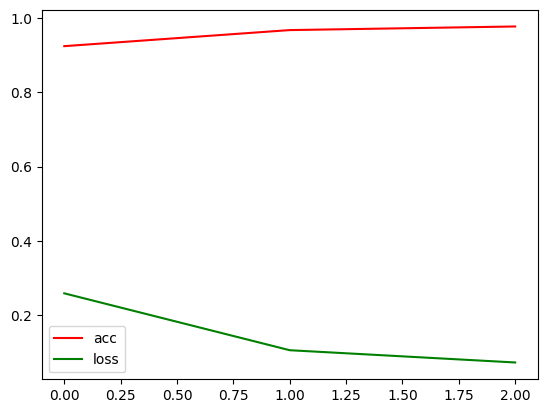

In [ ]:
plt.plot(hist.history['accuracy'], label='acc', color='red')
plt.plot(hist.history['loss'], label='loss', color='green')
plt.legend()

1/1 [==============================] - 0s 21ms/step
----------------
The predicted value is :  5
----------------


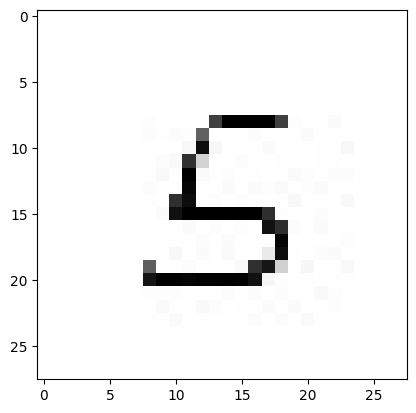

1/1 [==============================] - 0s 35ms/step
----------------
The predicted value is :  2
----------------


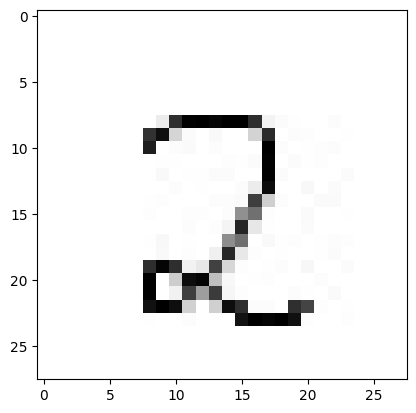

1/1 [==============================] - 0s 34ms/step
----------------
The predicted value is :  6
----------------


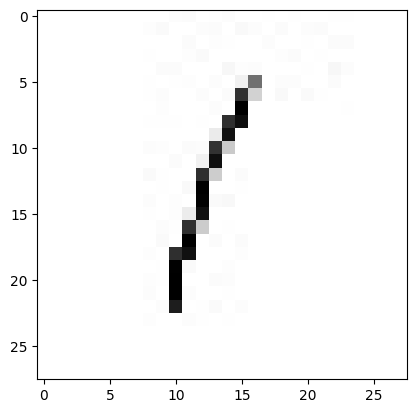

1/1 [==============================] - 0s 31ms/step
----------------
The predicted value is :  7
----------------


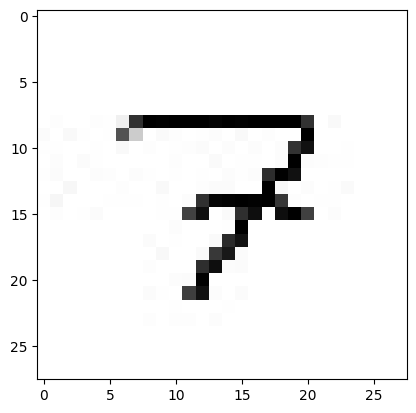

In [ ]:
for x in range(1,5):
  img=cv.imread(f'{x}.png')[:,:,0]#all of it and 1st and last one
  img=np.invert(np.array([img]))#invert black to white in images so that model wont get confues
  prediction=model.predict(img)
  print("----------------")
  print("The predicted value is : ",np.argmax(prediction))
  print("----------------")
  plt.imshow(img[0],cmap=plt.cm.binary)#change the color in black and white
  plt.show()
